<a href="https://colab.research.google.com/github/eleonoracasalee/ProgettoACC/blob/main/ProgettoACC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Impostazioni visualizzazione
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


In [3]:
df = pd.read_csv('/content/StudentPerformanceFactors.csv')
display(df.head(10))

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [4]:
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
print('=== NUMERICHE ===')
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .highlight_min('mean', color='lightcoral')

=== NUMERICHE ===


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.000000,19.975329,5.990594,1.000000,16.000000,20.000000,24.000000,44.000000
Attendance,6607.000000,79.977448,11.547475,60.000000,70.000000,80.000000,90.000000,100.000000
Sleep_Hours,6607.000000,7.029060,1.468120,4.000000,6.000000,7.000000,8.000000,10.000000
Previous_Scores,6607.000000,75.070531,14.399784,50.000000,63.000000,75.000000,88.000000,100.000000
Tutoring_Sessions,6607.000000,1.493719,1.230570,0.000000,1.000000,1.000000,2.000000,8.000000
Physical_Activity,6607.000000,2.967610,1.031231,0.000000,2.000000,3.000000,4.000000,6.000000
Exam_Score,6607.000000,67.235659,3.890456,55.000000,65.000000,67.000000,69.000000,101.000000


In [7]:
# Statistiche descrittive — colonne categoriche
print('=== CATEGORICHE ===')
df.describe(include=['object', 'string'])

=== CATEGORICHE ===


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


In [8]:
print('=== Valori Mancanti ===')
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_df.empty:
    display(missing_df.style.background_gradient(cmap='Reds'))
else:
    print('Non ci sono valori mancanti nel DataFrame.')

=== Valori Mancanti ===


,Missing Count,Missing Percentage (%)
Parental_Education_Level,90,1.362192
Teacher_Quality,78,1.180566
Distance_from_Home,67,1.014076


In [9]:
# Conteggio dei valori nulli per colonna
print("\nConteggio dei valori NaN/nulli:")
print(df.isnull().sum())


Conteggio dei valori NaN/nulli:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


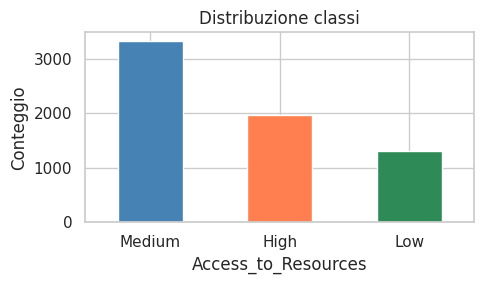

In [10]:
# Distribuzione delle classi
plt.figure(figsize=(5, 3))
df['Access_to_Resources'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
plt.title('Distribuzione classi')
plt.xlabel('Access_to_Resources')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

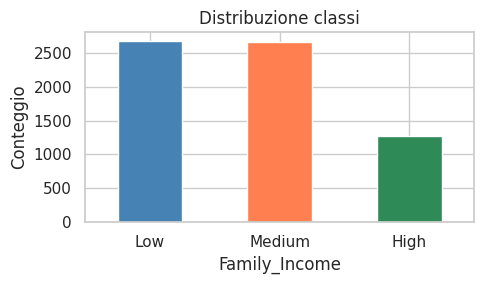

In [11]:
# Distribuzione delle classi
plt.figure(figsize=(5, 3))
df['Family_Income'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
plt.title('Distribuzione classi')
plt.xlabel('Family_Income')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

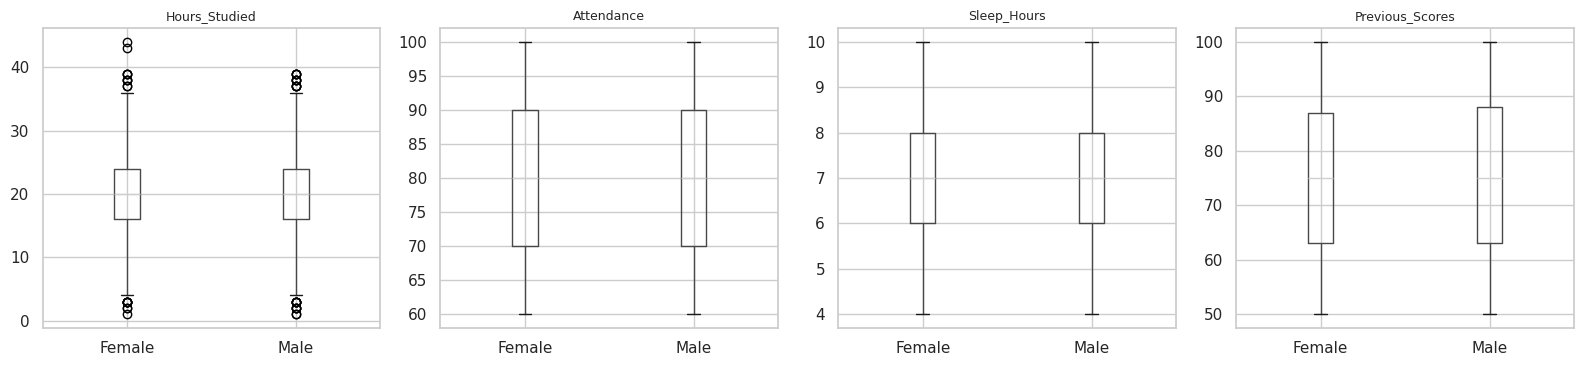

In [12]:
# Boxplot feature per classe
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
selected_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']
for ax, col in zip(axes, selected_features):
    df.boxplot(column=col, by='Gender', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

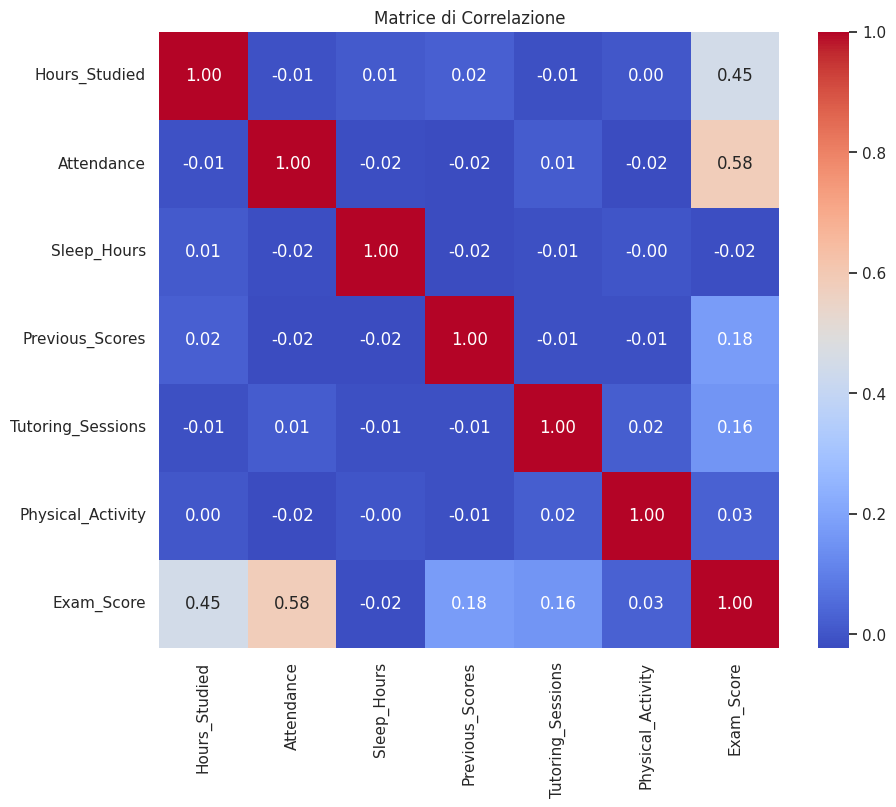

In [13]:
# Calcola la matrice di correlazione (solo per colonne numeriche)
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Visualizza la matrice di correlazione (opzionale ma utile)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice di Correlazione')
plt.show()

In [14]:
df[['Attendance', 'Hours_Studied', 'Previous_Scores']].corr()

,Attendance,Hours_Studied,Previous_Scores
Attendance,1.000,-0.010,-0.020
Hours_Studied,-0.010,1.000,0.025
Previous_Scores,-0.020,0.025,1.000


In [15]:
#PREPROCESSING

df_clean = df.copy()
print(f'Shape iniziale: {df_clean.shape}')

# 1. Caricamento del dataset
df_clean = pd.read_csv('StudentPerformanceFactors.csv')

# 2. Definizione delle mappe per l'Ordinal Encoding (ordine logico)
mappa_3_livelli = {'Low': 0, 'Medium': 1, 'High': 2}
mappa_peer = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
mappa_education = {'High School': 0, 'College': 1, 'Postgraduate': 2}
mappa_distanza = {'Near': 0, 'Moderate': 1, 'Far': 2}

# Applicazione del mapping alle colonne specifiche
df_clean['Access_to_Resources'] = df['Access_to_Resources'].map(mappa_3_livelli)
df_clean['Family_Income'] = df['Family_Income'].map(mappa_3_livelli)
df_clean['Parental_Involvement'] = df['Parental_Involvement'].map(mappa_3_livelli)
df_clean['Motivation_Level'] = df['Motivation_Level'].map(mappa_3_livelli)
df_clean['Teacher_Quality'] = df['Teacher_Quality'].map(mappa_3_livelli)
df_clean['Peer_Influence'] = df['Peer_Influence'].map(mappa_peer)
df_clean['Parental_Education_Level'] = df['Parental_Education_Level'].map(mappa_education)
df_clean['Distance_from_Home'] = df['Distance_from_Home'].map(mappa_distanza)

# 3. Gestione dei valori mancanti (NaN)
# Ora che le colonne sono numeriche, riempiamo i vuoti con la mediana
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# 4. One-Hot Encoding per le variabili senza ordine (0 o 1)
df_clean = pd.get_dummies(df_clean, columns=['Gender', 'School_Type', 'Internet_Access',
                                 'Extracurricular_Activities', 'Learning_Disabilities'],
                    drop_first=True)

# Salvataggio del file pulito per la fase di addestramento
df_clean.to_csv('StudentPerformance_Cleaned.csv', index=False)

print("Preprocessing completato. Righe nulle rimaste:", df_clean.isnull().sum().sum())
print(df_clean.head())

Shape iniziale: (6607, 20)
Preprocessing completato. Righe nulle rimaste: 0
   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     0                    2   
1             19          64                     0                    1   
2             24          98                     1                    1   
3             29          89                     0                    1   
4             19          92                     1                    1   

   Sleep_Hours  Previous_Scores  Motivation_Level  Tutoring_Sessions  \
0            7               73                 0                  0   
1            8               59                 0                  2   
2            7               91                 1                  2   
3            8               98                 1                  1   
4            6               65                 1                  3   

   Family_Income  Teacher_Quality  Peer_

In [16]:
print('=== RIEPILOGO PREPROCESSING ===')
print(f'  Shape originale  : {df.shape}')
print(f'  Shape finale     : {df_clean.shape}')
print(f'  Valori mancanti  : {df_clean.isnull().sum().sum()}')
print(f'  Tipi colonne     : {dict(df_clean.dtypes.value_counts())}')

df_clean.head()

=== RIEPILOGO PREPROCESSING ===
  Shape originale  : (6607, 20)
  Shape finale     : (6607, 20)
  Valori mancanti  : 0
  Tipi colonne     : {dtype('int64'): np.int64(12), dtype('bool'): np.int64(5), dtype('float64'): np.int64(3)}


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Gender_Male,School_Type_Public,Internet_Access_Yes,Extracurricular_Activities_Yes,Learning_Disabilities_Yes
0,23,84,0,2,7,73,0,0,0,1.000,2,3,0.000,0.000,67,True,True,True,False,False
1,19,64,0,1,8,59,0,2,1,1.000,0,4,1.000,1.000,61,False,True,True,False,False
2,24,98,1,1,7,91,1,2,1,1.000,1,4,2.000,0.000,74,True,True,True,True,False
3,29,89,0,1,8,98,1,1,1,1.000,0,4,0.000,1.000,71,True,True,True,True,False
4,19,92,1,1,6,65,1,3,1,2.000,1,4,1.000,0.000,70,False,True,True,True,False


In [17]:
#PREPROCESSING
from sklearn.model_selection import train_test_split

# Separazione tra variabili indipendenti e target
X = df_clean.drop('Exam_Score', axis=1)
y = df_clean['Exam_Score']

# Suddivisione del dataset in training e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} campioni')
print(f'Test:  {X_test.shape[0]} campioni')

Train: 5285 campioni
Test:  1322 campioni


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Pipeline per Regressione Lineare
pipeline_lr = Pipeline(steps=[
    ('regressor', LinearRegression())
])

# Pipeline per Random Forest
pipeline_rf = Pipeline(steps=[
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Allenamento e test
for name, pipe in [('Linear Regression', pipeline_lr), ('Random Forest', pipeline_rf)]:
    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    print(f"{name} - R^2 Score: {score:.4f}")

Linear Regression - R^2 Score: 0.7709
Random Forest - R^2 Score: 0.6654


In [ ]:
#addestramento e valutazione
# Fit
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Accuracy sul test set
acc_lr = pipe_lr.score(X_test, y_test)
acc_rf = pipe_rf.score(X_test, y_test)

print(f'Linear Regression — Test Accuracy: {acc_lr:.3f}')
print(f'Random Forest       — Test Accuracy: {acc_rf:.3f}')


Linear Regression — Test Accuracy: 0.771
Random Forest       — Test Accuracy: 0.266
